**1. Data setup**

**1a. Load in sEMG data from UCI ML Repository**

In [7]:
import pandas as pd
import glob
import os

def preprocess_emg_folder(folder_path):
    # all_windows = []
    # all_labels = []

    # Grab all subjects    
    folder_list = glob.glob(os.path.join(folder_path, "*/"))
    full_features = []
    full_lables = []
    for folder in folder_list:
        # Grab emg data files
        file_list = glob.glob(os.path.join(folder, "*.txt"))
        for file in file_list:
            # Load data: Time (0), Channels (1-8), Class (9)
            df = pd.read_csv(file, sep='\s+')
            
            # 1. Feature Extraction: (1-8)
            features = df.iloc[:, 1:9].values 
            
            # 2. Class Extraction: (9)
            labels = df.iloc[:, 9].values
            
            # 3. Clean Data: Remove unmarked data (class == '0')
            valid_indices = (labels != 0)
            features = features[valid_indices]
            labels = labels[valid_indices]
            
            # Shift labels 1-7 -> 0-6 for NN compatibility
            labels = labels - 1
            
            # append to full list of features & labels
            full_features.extend(features)
            full_lables.extend(labels)
    return full_features, full_lables

# raw data, not train/test split yet
X_raw, y_raw = preprocess_emg_folder('./Data')

**1b. Normalize + Clean data**

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_raw = scaler.fit_transform(X_raw)

# 1. Combine into a temporary DataFrame to keep rows aligned
temp_df = pd.DataFrame(X_raw)
temp_df['label'] = y_raw

# 2. Drop any row that has a NaN in either the features or the label
clean_df = temp_df.dropna()

# 3. Extract back into X and y
X_raw = clean_df.drop(columns=['label']).values
y_raw = clean_df['label'].values

**1c. Quick Check to view data**

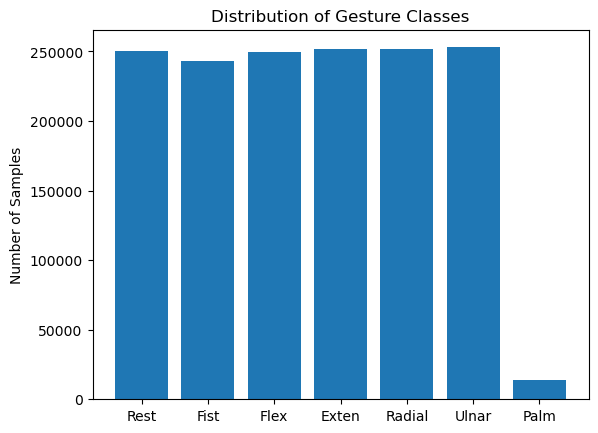

In [9]:
import matplotlib.pyplot as plt

# Check how many samples we have for each gesture
# Re-use for window data
plt.hist(y_raw, bins=range(8), align='left', rwidth=0.8)
plt.xticks(range(7), ['Rest', 'Fist', 'Flex', 'Exten', 'Radial', 'Ulnar', 'Palm'])
plt.title("Distribution of Gesture Classes")
plt.ylabel("Number of Samples")
plt.show()

**1d. Time-Window Data**

In [10]:
import numpy as np

# only accepts PERFECT WINDOWS (i.e doesn't fill with dumby 0's)
def create_windows_pure(X, y, window_size=64, stride=1):
    X_win = []
    y_win = []
    for i in range(0, len(y) - window_size + 1, stride):
        X_temp_window = X[i : i + window_size] 
        y_temp_window = y[i : i + window_size] 
        perfect, jump_val = isPure_window(y_temp_window)

        if not perfect:
            # INCOMPLETE, not needed with data this large.
            # might be helpful with FT on user data
            # jump by index instead of stride to not waste data 
            continue
        
        # We transpose so shape becomes (8, 64) instead of (64, 8)
        X_win.append(X_temp_window.T) 
        y_win.append(y[i])
        
    return np.array(X_win), np.array(y_win)


def isPure_window(y_win):
    prev = y_win[0]
    for i in range(len(y_win)):
        if y_win[i] != prev:
            return False, i
        else:
            prev = y_win[i]
    
    return True, 0  


def create_windows_majority(data, window_size=64, stride=1):
    pass


def create_windows_last(data, window_size=64, stride=1):
    pass

# Usage
X_win, y_win = create_windows_pure(X=X_raw, y=y_raw)
print(X_win.shape) 
print(y_win.shape)

(1457814, 8, 64)
(1457814,)


**1e. Train Test Split**

In [11]:
from sklearn.model_selection import train_test_split

RAND_NUM = 25

X_train, X_test, y_train, y_test = train_test_split(
    X_win,
    y_win,
    test_size=0.2,
    random_state=RAND_NUM,
    stratify=y_win,
)

**2. Setup Model Training**

**2a. Set up layers for CNN**

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleEMGFANet(nn.Module):
    def __init__(self, num_classes=7):
        super(SimpleEMGFANet, self).__init__()
        
        # Layer 1: Look for local patterns across the 8 channels
        # Input shape: (Batch, 8, Window_Size)
        # 8 due to the 8 channels of actual input data
        # 32 being a simple power of 2, big enough to capture complexity, small enough for laptop lol
        # 3 length of "filter" itself, smaller given high noise data like EMG
        # 1 gives data length same after convolution
        self.conv1 = nn.Conv1d(in_channels=8, out_channels=32, kernel_size=3, padding=1)
        
        # Layer 2: Deeper features
        # same as above, but with a second layer lol
        # higher scale given # of outputs from prev
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Layer 3: Channel Attention (The 'Adaptable' part of FANet)
        # Effictivly maps sensor vars to action
        # Ex: association between high activity in sensor 1 & 2 and fist gesture
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(64, 16, 1),
            nn.ReLU(),
            nn.Conv1d(16, 64, 1),
            nn.Sigmoid()
        )
        
        # Final Classifier
        self.fc = nn.Linear(64, num_classes)
    
    # function to allow forward pass through to begin training
    def forward(self, x):
        # 1. Feature Extraction
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        # 2. Apply Attention
        weights = self.attention(x)
        x = x * weights
        
        # 3. Global Average Pooling (reduces time dimension to 1)
        x = torch.mean(x, dim=2) 
        
        # 4. Classify
        x = self.fc(x)
        return x

# Instantiate the model
model = SimpleEMGFANet(num_classes=7)
print(model)

SimpleEMGFANet(
  (conv1): Conv1d(8, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (attention): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Conv1d(64, 16, kernel_size=(1,), stride=(1,))
    (2): ReLU()
    (3): Conv1d(16, 64, kernel_size=(1,), stride=(1,))
    (4): Sigmoid()
  )
  (fc): Linear(in_features=64, out_features=7, bias=True)
)


**2b. Prepare Loss Function**

In [13]:
import torch.optim as optim

device = torch.device("cpu")
model.to(device)

# Loss function to guide towards ideal weights
criterion = nn.CrossEntropyLoss()

# Optimizer to update actual weights of NN & MIN loss
# Adam specifically well adept to not geting stuck in local mins
# tracks velocity of weighting updates, allows to curve change if fickle
optimizer = optim.Adam(model.parameters(), lr=0.001)

**2c. Train Loader Setup**

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Wrap processed NumPy arrays into TensorDataset
# X_train: (Samples, 8, 64)
# y_train: (Samples,)
train_data_tensor = TensorDataset(
    torch.from_numpy(X_train).float(), 
    torch.from_numpy(y_train).long()
)
train_loader = DataLoader(
    train_data_tensor, 
    batch_size=32, 
    shuffle=True
)

test_data_tensor = TensorDataset(
    torch.from_numpy(X_test).float(), 
    torch.from_numpy(y_test).long()
)
test_loader = DataLoader(
    test_data_tensor, 
    batch_size=32, 
    shuffle=True
)

# Check the first batch
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(images.shape) # Should be [32, 8, 64]

torch.Size([32, 8, 64])


**3 TRAIN**


In [19]:
def trainCNN_EMG(epochs: int):
    train_losses = []

    for epoch in range(epochs):
        model.train() 
        total_loss = 0.0
        
        for inputs, labels in train_loader:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 1. Zero the gradients (clear prev memory)
            optimizer.zero_grad()
            
            # 2. Forward pass: Compute predicted outputs
            outputs = model(inputs)
            
            # 3. Calculate loss
            # using Cross Entropy Loss
            loss = criterion(outputs, labels)
            
            # 4. Backward pass: Compute gradient of the loss with respect to model parameters
            loss.backward()
            
            # 5. Perform single optimization step (parameter update)
            # using Adam
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    print("Finished Training")


# arbitrary epochs
trainCNN_EMG(epochs=5)

Epoch [1/5], Loss: 0.3991
Epoch [2/5], Loss: 0.2865
Epoch [3/5], Loss: 0.2509
Epoch [4/5], Loss: 0.2273
Epoch [5/5], Loss: 0.2078
Finished Training


**3a. Save model**

In [20]:
import pickle
import os

MODELFILE = os.path.join("./model", "sEMG_CNN.pkl")
pickle.dump(model, open(MODELFILE, 'wb'))

**4. Evaluate Model**

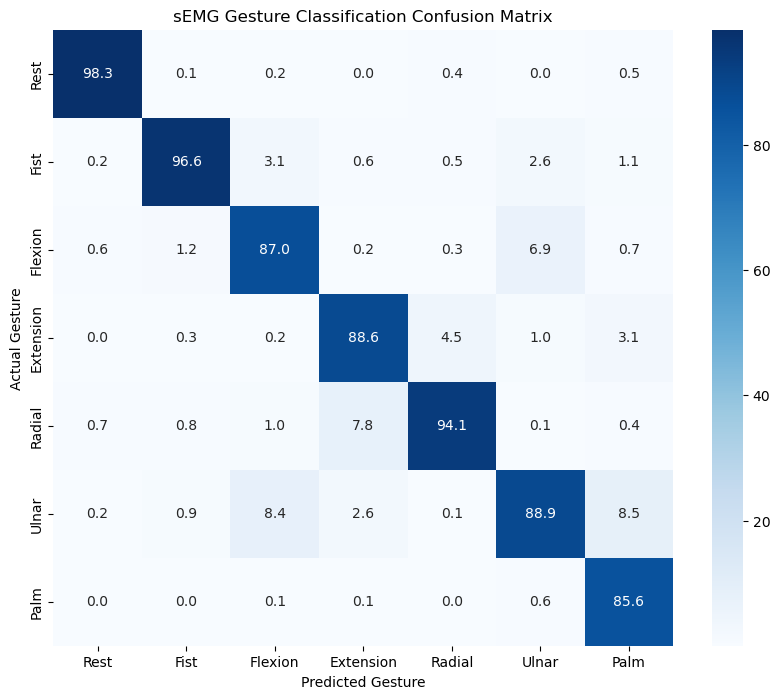


Classification Report:

              precision    recall  f1-score   support

        Rest       0.98      0.99      0.99     48197
        Fist       0.97      0.93      0.95     46824
     Flexion       0.87      0.91      0.89     48084
   Extension       0.89      0.94      0.91     48500
      Radial       0.94      0.89      0.92     48532
       Ulnar       0.89      0.87      0.88     48788
        Palm       0.86      0.83      0.84      2638

    accuracy                           0.92    291563
   macro avg       0.91      0.91      0.91    291563
weighted avg       0.92      0.92      0.92    291563



In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []
    
    with torch.no_grad(): # No need to track gradients during testing
        for inputs, labels in test_loader:
            # Forward pass
            outputs = model(inputs)
            
            # Get the index of the highest value (the predicted class)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# 1. Run Evaluation
y_true, y_pred = evaluate_model(model, test_loader)

# 2. Define Gesture Names for clarity
gesture_names = ['Rest', 'Fist', 'Flexion', 'Extension', 'Radial', 'Ulnar', 'Palm']

# 3. Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_perc = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :] * 100

# 4. Plot using Seaborn for a cuter look
plt.figure(figsize=(10, 8))
sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=gesture_names, 
            yticklabels=gesture_names)
plt.xlabel('Predicted Gesture')
plt.ylabel('Actual Gesture')
plt.title('sEMG Gesture Classification Confusion Matrix')
plt.show()

# 5. Print Detailed Metrics
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=gesture_names))